In [14]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

#loading data
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#data cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [15]:
#only get data analyst jobs in the us
df_da_us=df[(df['job_title_short']=='Data Analyst')& (df['job_country']=='United States')].copy()

Text(0, 0.5, 'number of jobs')

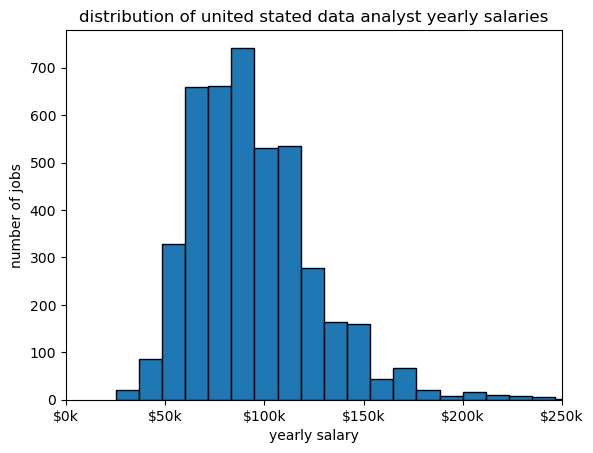

In [16]:
df_da_us['salary_year_avg'].plot(kind='hist' , bins=30, edgecolor='black')
plt.xlim(0, 250000)

ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))

plt.title('distribution of united stated data analyst yearly salaries')
plt.xlabel('yearly salary')
plt.ylabel('number of jobs')